In [1]:
%load_ext autoreload
%autoreload 2

import data_analysis as da

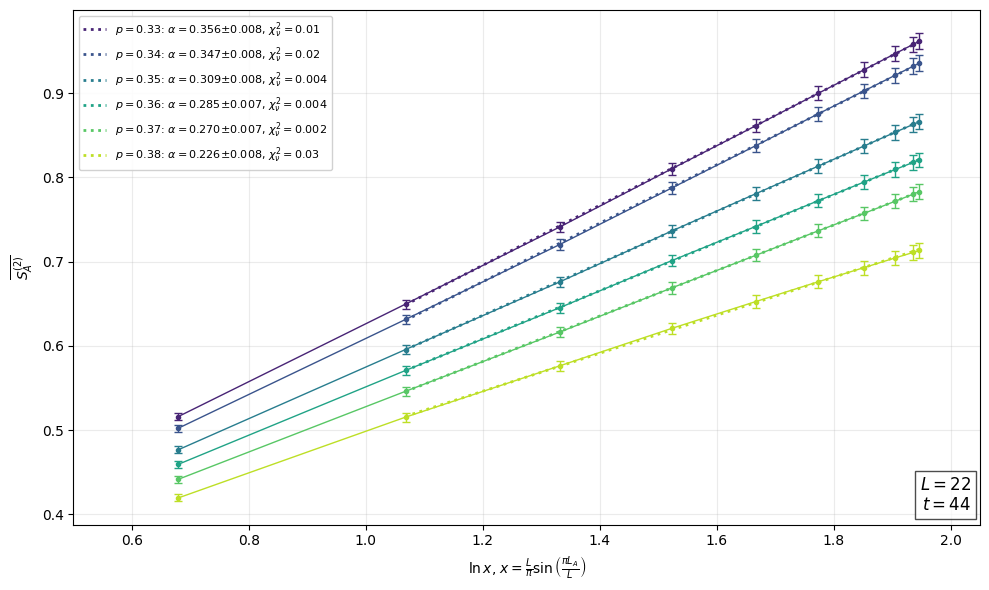

In [2]:
entropy_files = [
    f"cpp/csv/entropy/entropy_n22_p{p}_circ2_real1000.csv"
    for p in ["0.33", "0.34", "0.35", "0.36", "0.37", "0.38"]
]

entropy = da.entropy(
    entropy_files,
    fit_above_p=0.30,
    exclude_first=1,
    uncertainty="S2_stderr",
)

/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/fssa/__init__.py:83: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Importing L=12: cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv
Importing L=16: cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv
Importing L=20: cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv
p-grid alignment: interpolated, 11 points
p_c = 0.355 ± 0.016
nu  = 2.9442552 ± 3
zeta = 0 fixed
collapse quality S = 17.589208
The collapse is very poor under the assumed scaling ansatz.


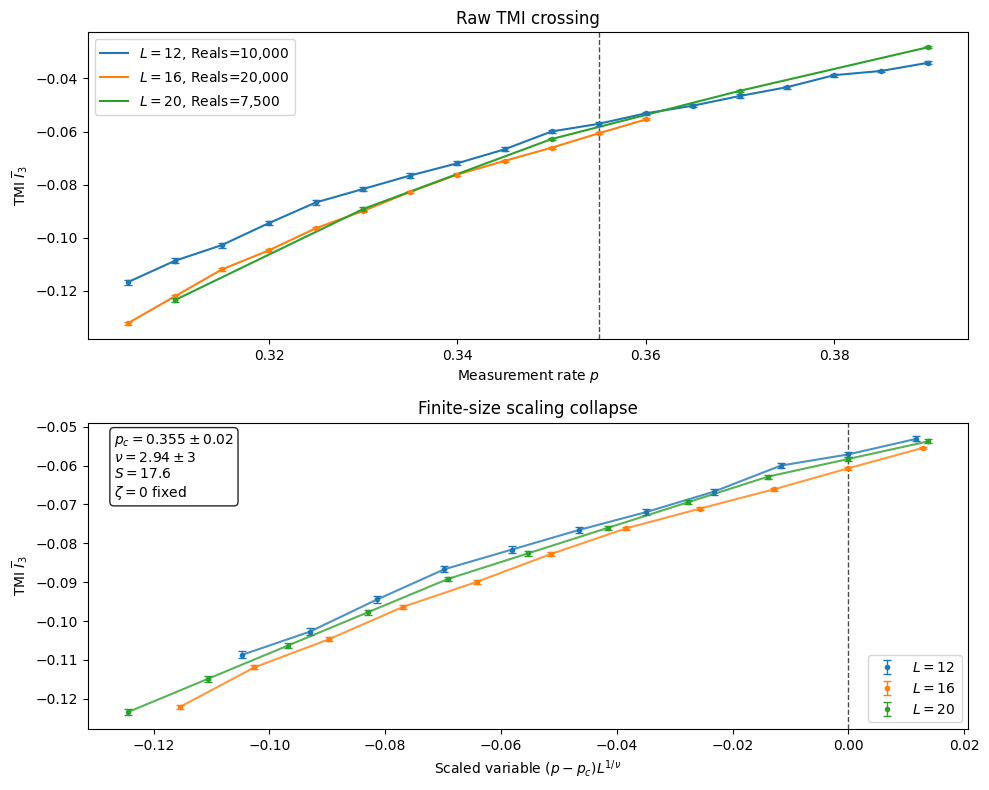

In [3]:
tmi = da.tmi_collapse(
    files=[
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv",
    ],
    sizes=[12, 16, 20],
    realizations=[10_000, 20_000, 7_500],
    p_range=(0.30, 0.39),
    pc0=0.33,
    nu0=2.0,
    fit_zeta=False,
)

Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
z   = 1.046634 ± 0.008548
x_A = 0.226635 ± 0.006439
collapse score = 0.414211


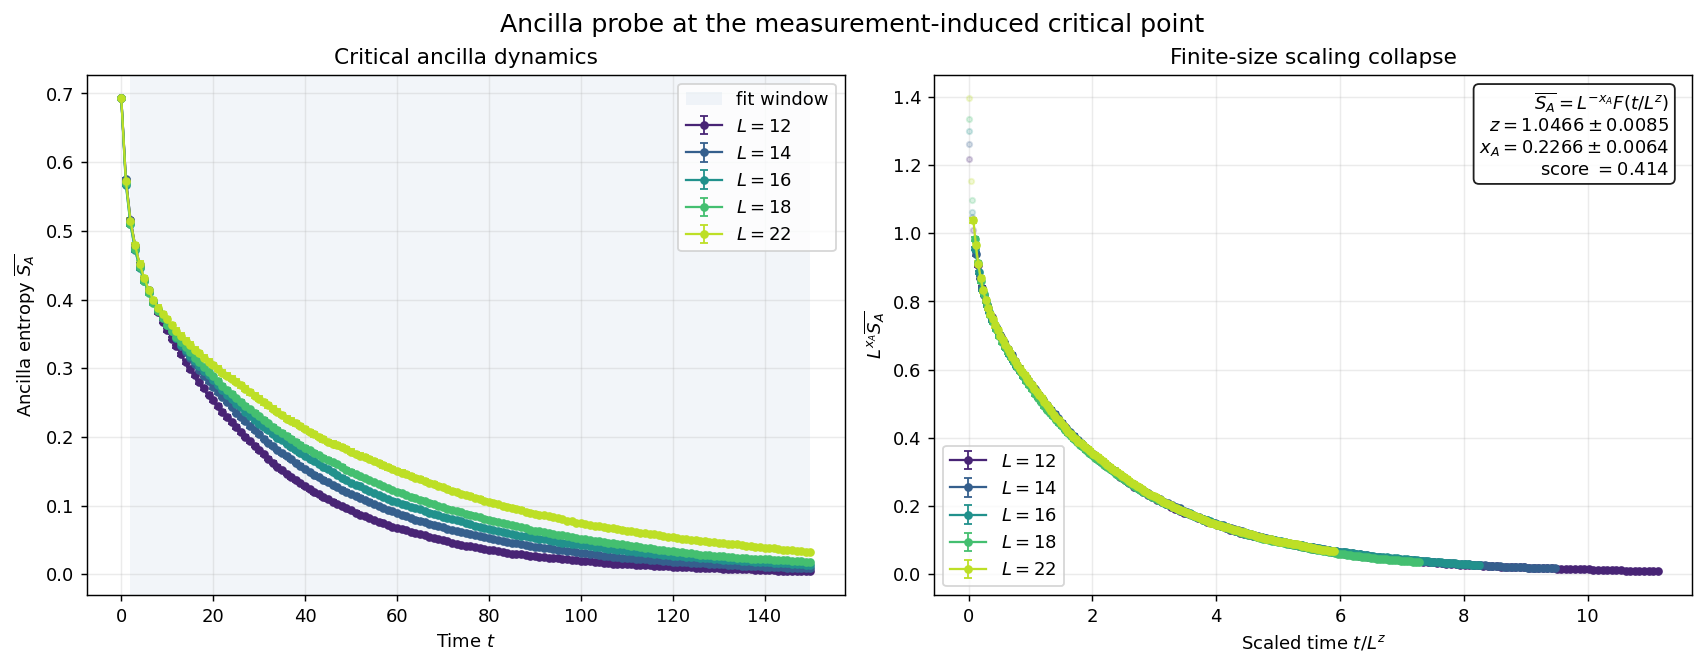

In [5]:
probe1 = da.probe1_collapse(
    file_glob="cpp/csv/probed/t_150/probed_rppu_n_*_p_0.333_d_1_*.csv",
    t_max=150,
    fit_t=(2, None),
    fixed_x_a=None,               # None fits both z and x_A
    z_bounds=(0.4, 2.5),
    bootstrap_samples=200,
    collapse_xscale="linear",
)

,L,p_from_filename,points,x_min,x_max,I_max,x_at_I_max,file
0,8,0.333,65,0.0,8.0,0.592108,8.0,cpp/csv/2probed/reals_2500/2probed_rppu_n_8_p_...
1,12,0.333,97,0.0,8.0,0.548100,8.0,cpp/csv/2probed/reals_2500/2probed_rppu_n_12_p...
2,16,0.333,129,0.0,8.0,0.517328,8.0,cpp/csv/2probed/reals_2500/2probed_rppu_n_16_p...
3,20,0.333,161,0.0,8.0,0.496884,8.0,cpp/csv/2probed/reals_2500/2probed_rppu_n_20_p...


Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
eta = 0.191827 ± 0.002805
bootstrap 68% interval = [0.188821, 0.194531]
collapse score = 0.132958


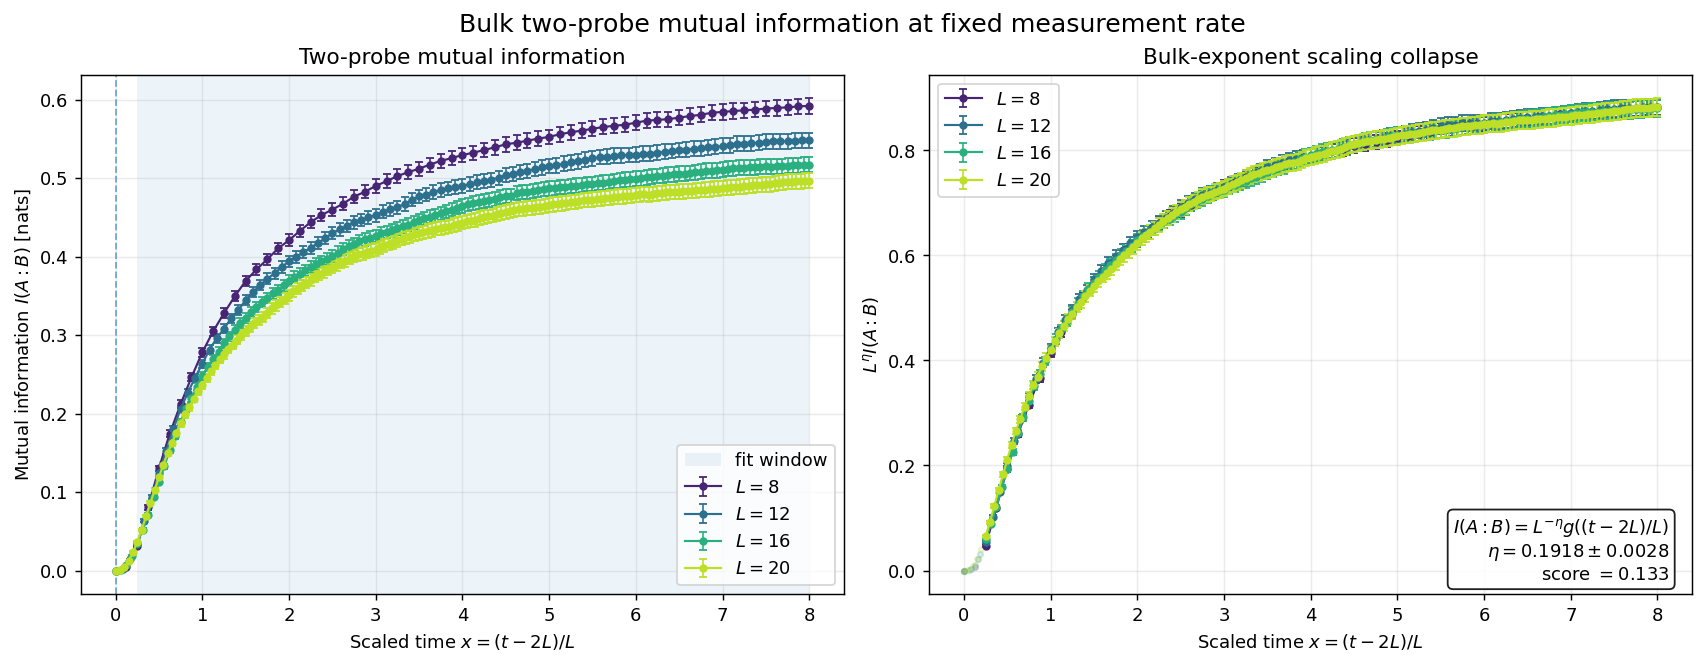

In [9]:
probe2 = da.probe2_collapse(
    file_glob="cpp/csv/2probed/reals_2500/2probed_rppu_n_*_p_0.333_*.csv",
    x_load=(None, None),
    fit_x=(0.25, 8.0),
    fit_i_min=1e-8,
    eta_bounds=(0.0, 2.0),
    bootstrap_samples=200,
)

Importing L=18: cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_18_periods_36_p_0.333_real_1000.csv


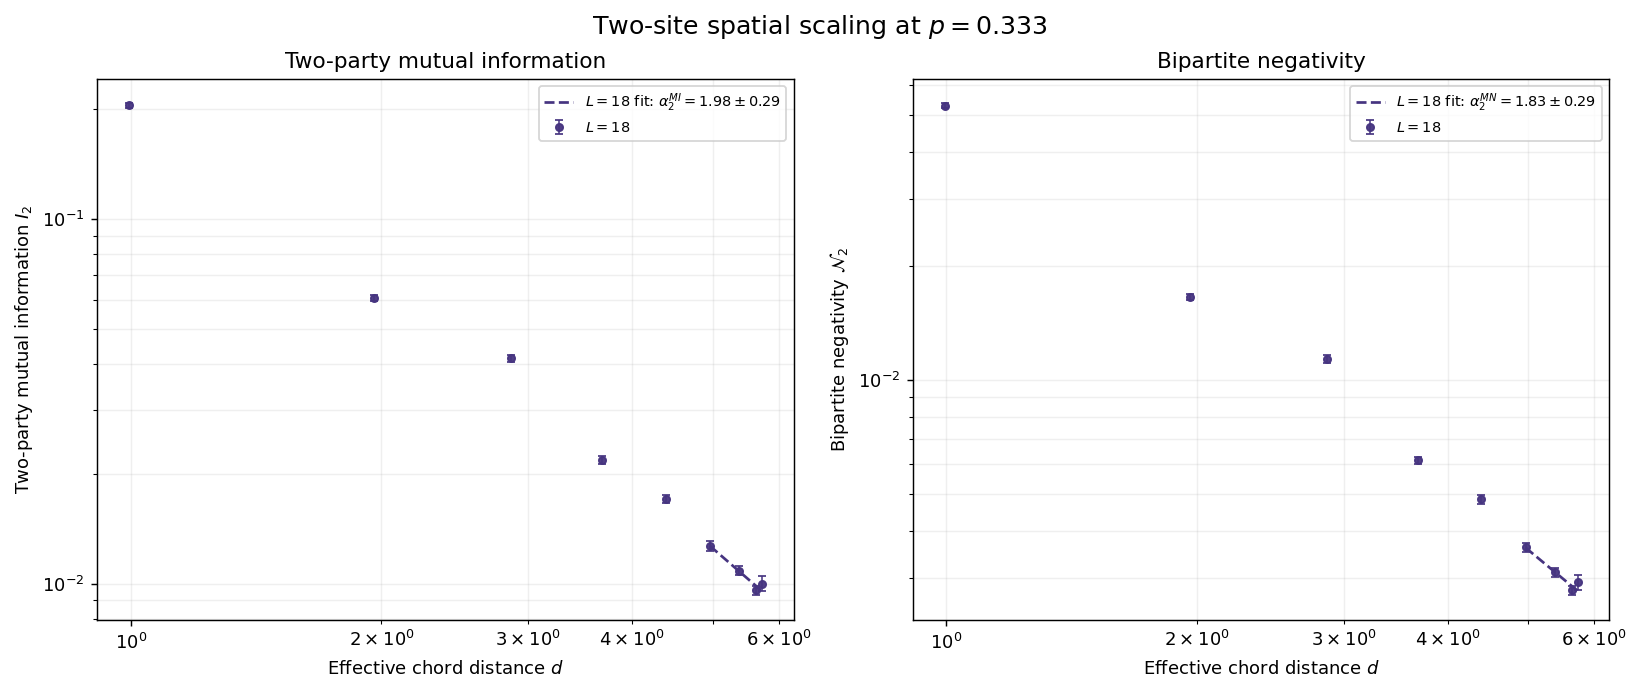

,L,file,distance_points_mi,distance_points_mn,rows_mi,rows_mn
0,18,cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_...,9,9,153000,153000


,L,metric,alpha,alpha_stderr,prefactor,log_prefactor,log_prefactor_stderr,reduced_chi2,d_min,d_max,points
0,18,mi,1.983970,0.294584,0.304356,-1.189558,0.495265,0.922679,4.96196,5.729578,4
1,18,mn,1.825879,0.291887,0.067248,-2.699372,0.491031,1.019050,4.96196,5.729578,4


,L,metric,alpha,alpha_stderr,prefactor,log_prefactor,log_prefactor_stderr,reduced_chi2,d_min,d_max,points
0,18,mi,1.983970,0.294584,0.304356,-1.189558,0.495265,0.922679,4.96196,5.729578,4
1,18,mn,1.825879,0.291887,0.067248,-2.699372,0.491031,1.019050,4.96196,5.729578,4


In [13]:
import importlib
import data_analysis

# Reload after replacing data_analysis.py.
importlib.reload(data_analysis)

# ------------------------------------------------------------------
# Input files
# The sizes can also be inferred automatically from "_n_<N>_" in
# each filename. Supplying SIZES explicitly makes the setup clearer.
# ------------------------------------------------------------------
FILES = [
    "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_18_periods_36_p_0.333_real_1000.csv",
]

SIZES = [18]

# ------------------------------------------------------------------
# Fit controls
#
# None means: use the FIT_LAST_* largest positive-distance points.
#
# A common explicit distance window can instead be given as:
# FIT_RANGE_MI = (3.0, 6.0)
#
# Different windows for different sizes are also supported:
# FIT_RANGE_MI = {
#     12: (2.0, 3.8),
#     16: (3.0, 5.0),
#     20: (4.0, 6.4),
# }
# ------------------------------------------------------------------
FIT_RANGE_MI = None
FIT_RANGE_MN = None

FIT_LAST_MI = 4
FIT_LAST_MN = 4

# Dashed lines are plotted for these sizes.
# Fits for every size remain available in result["fits"].
FIT_SIZE_MI = max(SIZES)
FIT_SIZE_MN = max(SIZES)

result = data_analysis.dist_scaling(
    files=FILES,
    sizes=SIZES,

    fit_size_mi=FIT_SIZE_MI,
    fit_size_mn=FIT_SIZE_MN,

    fit_range_mi=FIT_RANGE_MI,
    fit_range_mn=FIT_RANGE_MN,
    fit_last_mi=FIT_LAST_MI,
    fit_last_mn=FIT_LAST_MN,

    min_relative_error=0.03,
    chunksize=1_000_000,

    title=r"Two-site spatial scaling at $p=0.333$",
)

# Numerical fit results:
result["fits"]